# TT-30 — SARIMA dự báo lượng khách hàng tháng

In [4]:
import os, itertools, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore"); pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})

# Thư mục lưu kết quả (tạo cạnh notebook, không cần cấu trúc thư mục đặc biệt)
OUT = "../reports"; os.makedirs(OUT, exist_ok=True); os.makedirs("../models", exist_ok=True)

In [5]:
def load_airpassengers() -> pd.Series:
    df = sm.datasets.get_rdataset("AirPassengers").data   # cần internet
    return pd.Series(df["value"].values,
                     index=pd.date_range("1949-01-01", periods=len(df), freq="MS"), name="khach")

def bang_adf(y: pd.Series) -> pd.DataFrame:
    y_log = np.log(y)
    phien_ban = {"Gốc": y, "Log": y_log, "Log + diff(1)": y_log.diff(1),
                 "Log + diff(1) + diff(12)": y_log.diff(1).diff(12)}
    rows = []
    for ten, s in phien_ban.items():
        stat, p, *_ = adfuller(s.dropna())
        rows.append([ten, round(stat, 3), round(p, 4), "DỪNG" if p < 0.05 else "KHÔNG DỪNG"])
    return pd.DataFrame(rows, columns=["Phiên bản", "ADF stat", "p-value", "Kết luận"])

def mape(thuc, dubao) -> float:
    thuc, dubao = np.asarray(thuc), np.asarray(dubao)
    return float(np.mean(np.abs((thuc - dubao) / thuc)) * 100)

def chia_train_test(y, n_test=24):
    return y.iloc[:-n_test], y.iloc[-n_test:]

def baselines(train, test):
    naive = pd.Series(train.iloc[-1], index=test.index)
    reps = int(np.ceil(len(test) / 12))
    snaive = pd.Series(np.tile(train.iloc[-12:].values, reps)[: len(test)], index=test.index)
    return {"Naive": naive, "Seasonal naive": snaive}

def fit_sarima(y_log, order, seasonal_order):
    # Giữ mặc định enforce_stationarity/invertibility=True: tắt chúng làm AIC bị méo
    return SARIMAX(y_log, order=order, seasonal_order=seasonal_order).fit(disp=False)

def quet_luoi(y_log, d=1, D=1, s=12, rng_pq=(0, 1, 2), rng_PQ=(0, 1)) -> pd.DataFrame:
    ket_qua = []
    for p, q, P, Q in itertools.product(rng_pq, rng_pq, rng_PQ, rng_PQ):
        try:
            f = fit_sarima(y_log, (p, d, q), (P, D, Q, s))
            ket_qua.append([(p, d, q), (P, D, Q, s), f.aic])
        except Exception:
            continue
    return (pd.DataFrame(ket_qua, columns=["order", "seasonal", "AIC"])
            .sort_values("AIC").reset_index(drop=True))

def du_bao(fit, steps=24, alpha=0.05):
    kq = fit.get_forecast(steps=steps)
    mean = np.exp(kq.predicted_mean)              # đổi ngược từ log
    ci = np.exp(kq.conf_int(alpha=alpha)); ci.columns = ["thap", "cao"]
    return mean, ci

def ti_le_phu(test, ci) -> float:
    return float(((test >= ci["thap"]) & (test <= ci["cao"])).mean() * 100)

In [6]:
y = load_airpassengers()
print(y.shape, y.index[0].date(), "→", y.index[-1].date())

(144,) 1949-01-01 → 1960-12-01


## 1. Nhìn chuỗi gốc
Có **xu hướng tăng** và **mùa vụ 12 tháng**, và biên độ mùa vụ **phình dần** — dấu hiệu của mô hình nhân tính.

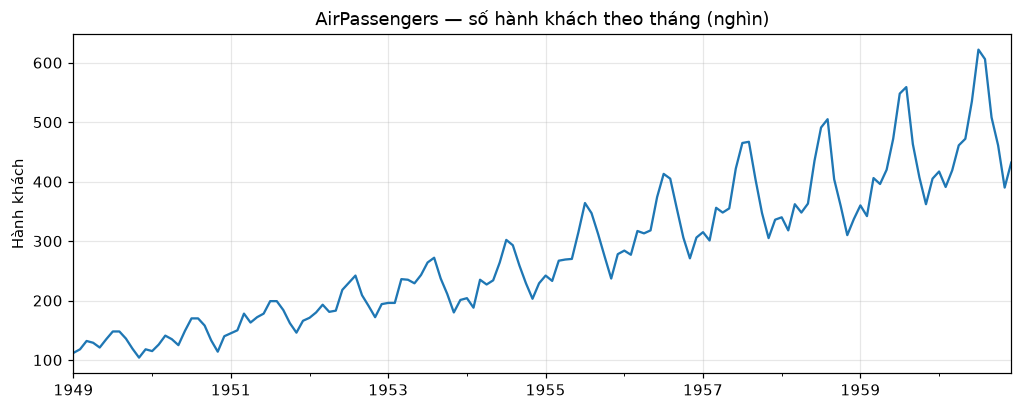

In [7]:
fig, ax = plt.subplots(figsize=(11,4)); y.plot(ax=ax, title="AirPassengers — số hành khách theo tháng (nghìn)")
ax.set_ylabel("Hành khách"); plt.show()

## 2. Phân rã cộng tính vs nhân tính
Mô hình đúng sẽ cho **phần dư dao động đều quanh mức trung tính**. Phần dư của mô hình sai sẽ xòe rộng dần.

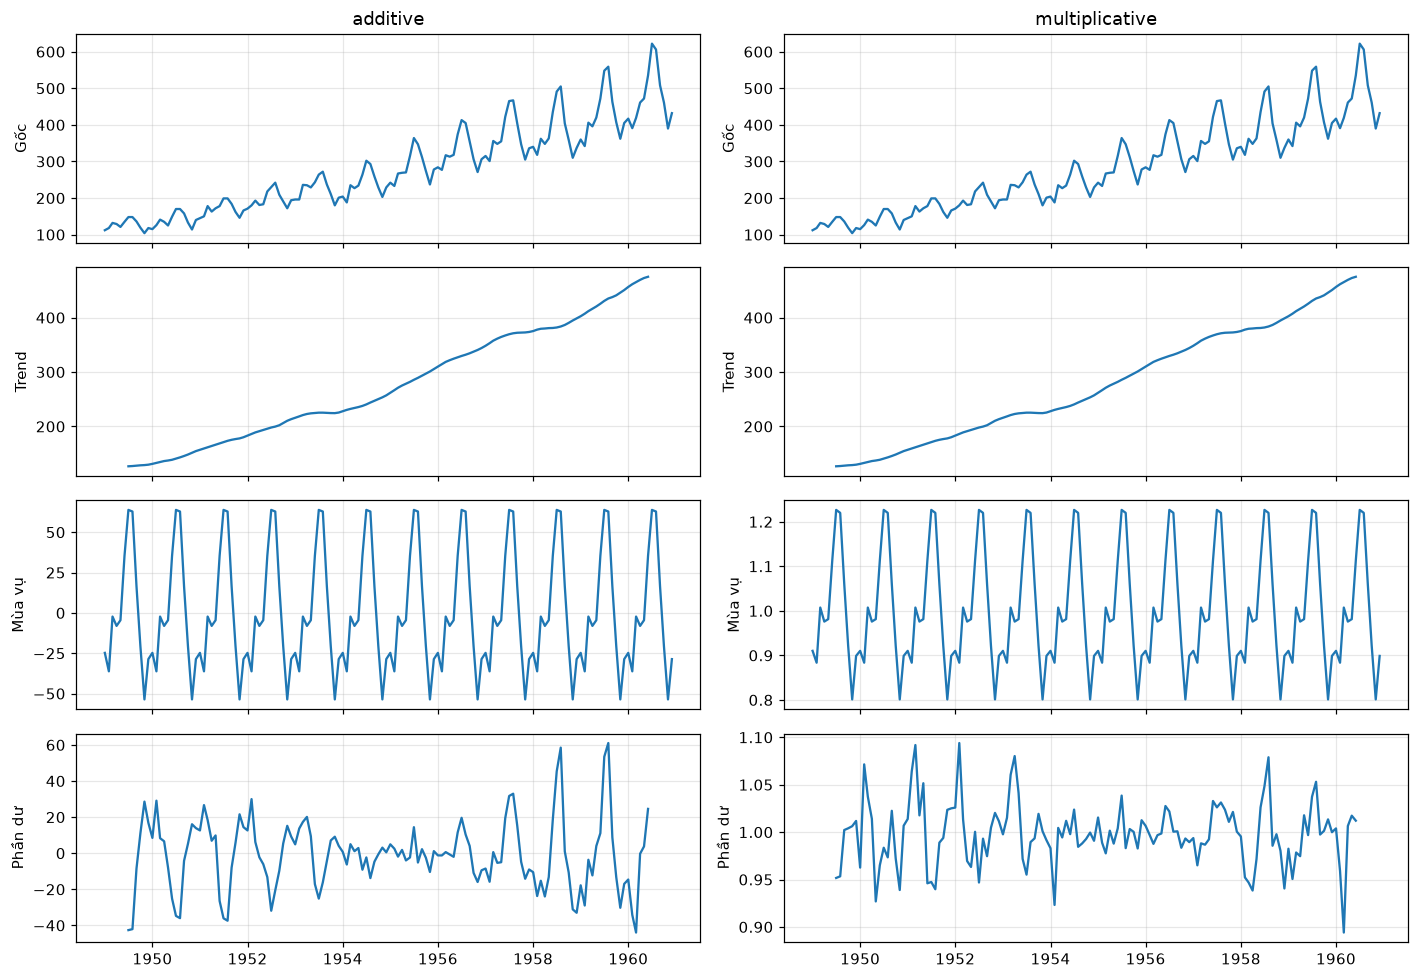

Độ lệch chuẩn phần dư nửa đầu vs nửa sau chuỗi:
  additive        đầu = 1.25 | sau = 1.44 | tỉ lệ sau/đầu = 1.15
  multiplicative  đầu = 1.54 | sau = 1.20 | tỉ lệ sau/đầu = 0.78


In [8]:
fig, axes = plt.subplots(4, 2, figsize=(13, 9), sharex="col")
for j, m in enumerate(["additive", "multiplicative"]):
    r = seasonal_decompose(y, model=m, period=12)
    for i, (comp, name) in enumerate([(r.observed,"Gốc"),(r.trend,"Trend"),(r.seasonal,"Mùa vụ"),(r.resid,"Phần dư")]):
        axes[i, j].plot(comp); axes[i, j].set_ylabel(name)
    axes[0, j].set_title(m)
plt.tight_layout(); plt.savefig(f"{OUT}/decompose.png"); plt.show()
ra = seasonal_decompose(y, model="additive", period=12).resid.dropna()
rm = seasonal_decompose(y, model="multiplicative", period=12).resid.dropna()
print("Độ lệch chuẩn phần dư nửa đầu vs nửa sau chuỗi:")
for ten, r in [("additive", ra/ra.abs().mean()), ("multiplicative", (rm-1)/ (rm-1).abs().mean())]:
    h = len(r)//2; print(f"  {ten:15s} đầu = {r.iloc[:h].std():.2f} | sau = {r.iloc[h:].std():.2f} | tỉ lệ sau/đầu = {r.iloc[h:].std()/r.iloc[:h].std():.2f}")

## 3. Lấy log
Vì $\log(a\cdot b)=\log a+\log b$, phép nhân thành phép cộng, và ARIMA là mô hình cộng.

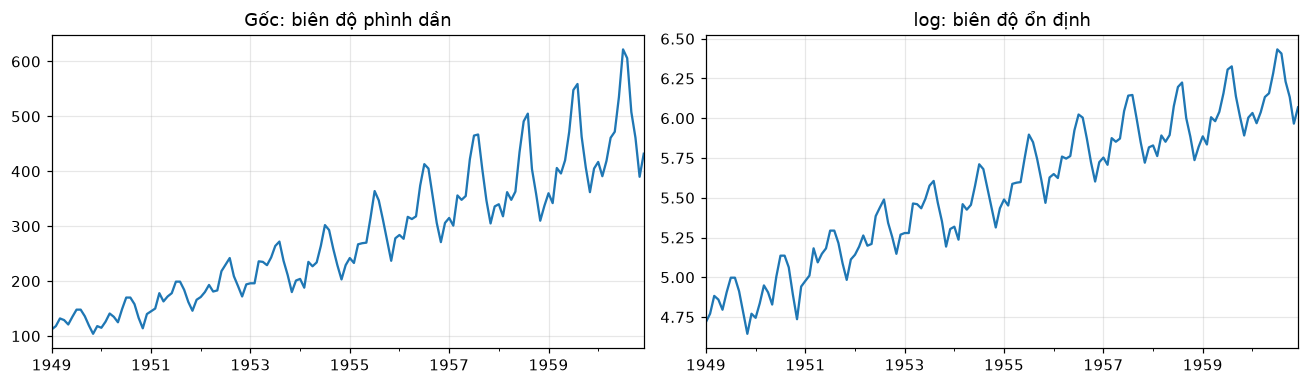

In [9]:
y_log = np.log(y)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
y.plot(ax=ax[0], title="Gốc: biên độ phình dần"); y_log.plot(ax=ax[1], title="log: biên độ ổn định")
plt.tight_layout(); plt.show()

## 4. Bảng ADF — xác định d và D
H₀ của ADF là *chuỗi không dừng*, nên **p < 0,05 mới đạt**.

In [10]:
bang = bang_adf(y); bang

,Phiên bản,ADF stat,p-value,Kết luận
0,Gốc,0.815,0.9919,KHÔNG DỪNG
1,Log,-1.717,0.4224,KHÔNG DỪNG
2,Log + diff(1),-2.717,0.0711,KHÔNG DỪNG
3,Log + diff(1) + diff(12),-4.443,0.0002,DỪNG


## 5. ACF / PACF của chuỗi đã dừng
Quy tắc: ACF cắt đột ngột sau lag q → MA(q); PACF cắt đột ngột sau lag p → AR(p). Lag 12, 24, 36 cho phần mùa vụ (Q, P).

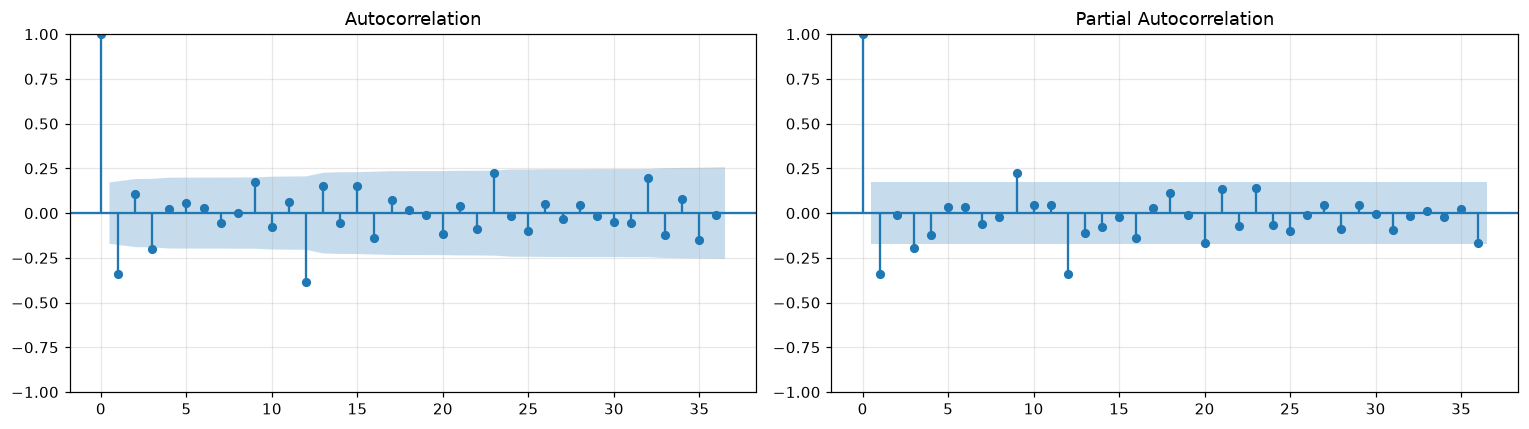

In [11]:
y_dung = y_log.diff(1).diff(12).dropna()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_dung, lags=36, ax=ax[0]); plot_pacf(y_dung, lags=36, ax=ax[1], method="ywm")
plt.tight_layout(); plt.savefig(f"{OUT}/acf_pacf.png"); plt.show()

## 6–7. Chia train/test và baseline
Chia **theo thời gian**: 120 tháng train (1949–1958), 24 tháng test (1959–1960).

In [12]:
train, test = chia_train_test(y, 24); train_log = np.log(train)
bl = baselines(train, test)
bang_bl = pd.DataFrame({"MAPE (%)": {k: mape(test, v) for k, v in bl.items()}}).round(2); bang_bl

,MAPE (%)
Naive,23.58
Seasonal naive,15.52


## 8. SARIMA thủ công
Hai ứng viên: (a) airline model đọc từ ACF/PACF, (b) (1,1,1)(1,1,1,12) điểm xuất phát của đề.

In [13]:
fit_air = fit_sarima(train_log, (0,1,1), (0,1,1,12))
fit_111 = fit_sarima(train_log, (1,1,1), (1,1,1,12))
print(fit_air.summary().tables[1]); print(); print(fit_111.summary().tables[1])
print(f"\nAIC airline = {fit_air.aic:.1f} | AIC (1,1,1)(1,1,1,12) = {fit_111.aic:.1f}")

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3425      0.087     -3.923      0.000      -0.514      -0.171
ma.S.L12      -0.5406      0.105     -5.156      0.000      -0.746      -0.335
sigma2         0.0014      0.000      7.865      0.000       0.001       0.002

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2044      0.266      0.768      0.442      -0.317       0.726
ma.L1         -0.5415      0.239     -2.263      0.024      -1.010      -0.073
ar.S.L12      -0.0700      0.249     -0.281      0.779      -0.558       0.418
ma.S.L12      -0.4945      0.268     -1.846      0.065      -1.020       0.031
sigma2         0.0014      0.000      7.212      0.000       0.001       0.002

AIC airline = -389.0 | AIC (1,1,1)(1,1,1,12) = -38

## 9. Dò lưới theo AIC
Cố định d = D = 1, quét p, q ∈ {0,1,2} và P, Q ∈ {0,1}.

In [14]:
luoi = quet_luoi(train_log); luoi.head(8)

,order,seasonal,AIC
0,"(0, 1, 1)","(0, 1, 1, 12)",-389.009747
1,"(1, 1, 0)","(0, 1, 1, 12)",-388.643165
2,"(1, 1, 1)","(0, 1, 1, 12)",-387.278948
3,"(0, 1, 1)","(1, 1, 1, 12)",-387.220082
4,"(0, 1, 2)","(0, 1, 1, 12)",-387.065405
5,"(1, 1, 0)","(1, 1, 1, 12)",-386.774619
6,"(2, 1, 0)","(0, 1, 1, 12)",-386.657937
7,"(2, 1, 1)","(0, 1, 1, 12)",-386.612326


In [15]:
best_order, best_seasonal = luoi.iloc[0]["order"], luoi.iloc[0]["seasonal"]
print("Bậc chọn bởi AIC:", best_order, best_seasonal)
fit = fit_sarima(train_log, best_order, best_seasonal)

Bậc chọn bởi AIC: (0, 1, 1) (0, 1, 1, 12)


## 10. Kiểm tra phần dư
Bỏ 13 phần dư đầu (d + s·D = 1 + 12) vì đó là giai đoạn khởi tạo của sai phân. Cần **p-value > 0,05** (phần dư là nhiễu trắng).

In [16]:
def ljung(f, ten):
    lb = acorr_ljungbox(f.resid.iloc[13:], lags=[12, 24], return_df=True)
    lb.insert(0, "Model", ten); return lb
bang_lb = pd.concat([ljung(fit, f"Chọn theo AIC {best_order}{best_seasonal}"), ljung(fit_111, "(1,1,1)(1,1,1,12)")]).round(3)
bang_lb

,Model,lb_stat,lb_pvalue
12,"Chọn theo AIC (0, 1, 1)(0, 1, 1, 12)",6.073,0.912
24,"Chọn theo AIC (0, 1, 1)(0, 1, 1, 12)",17.985,0.804
12,"(1,1,1)(1,1,1,12)",5.081,0.955
24,"(1,1,1)(1,1,1,12)",16.613,0.865


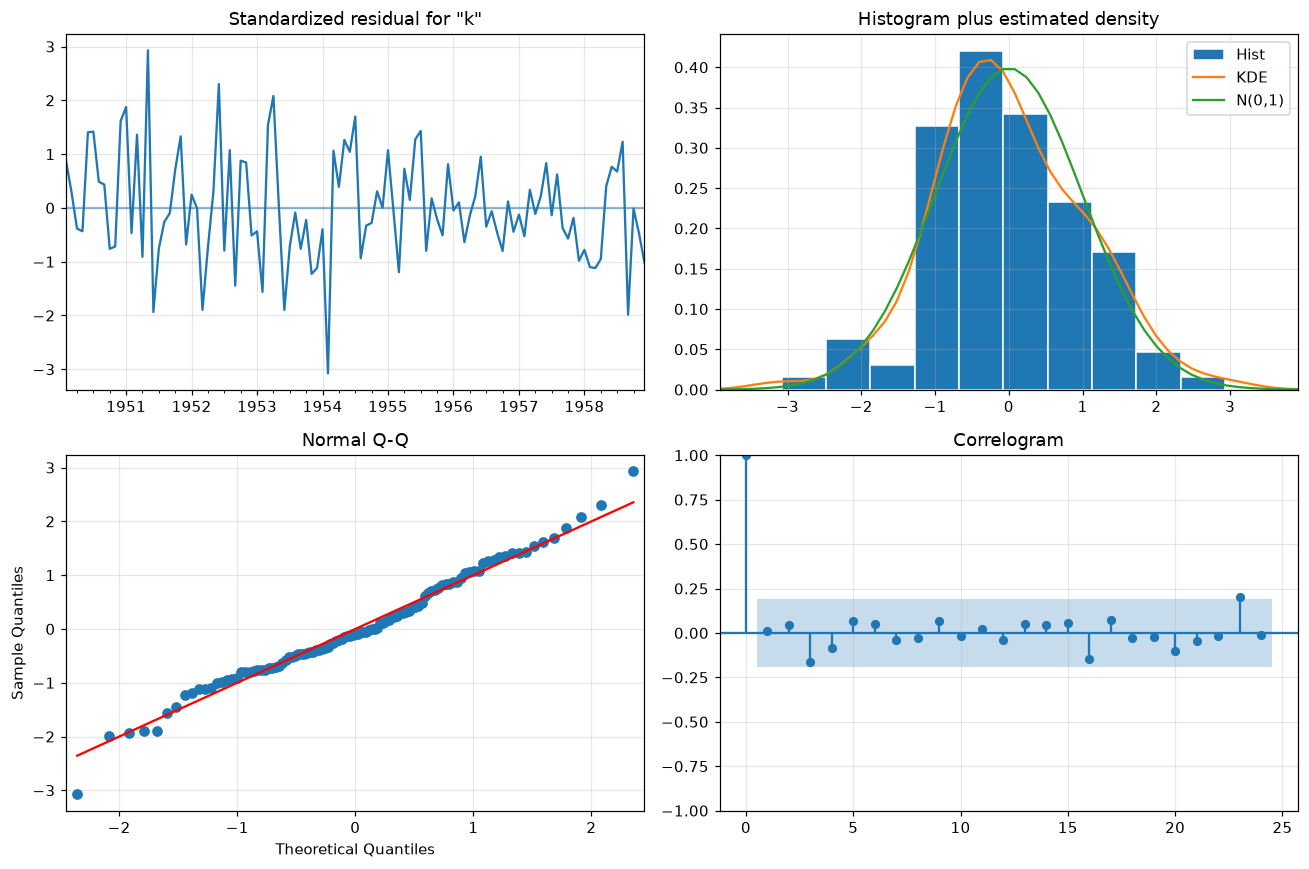

In [17]:
fig = fit.plot_diagnostics(figsize=(12, 8), lags=24); plt.tight_layout()
plt.savefig(f"{OUT}/residual_diagnostics.png"); plt.show()

## 11–13. Dự báo 24 tháng, MAPE, tỉ lệ phủ

In [18]:
mean, ci = du_bao(fit, 24)
mean_111, ci_111 = du_bao(fit_111, 24)
ket_qua = pd.DataFrame({
    "MAPE (%)": {"Naive": mape(test, bl["Naive"]), "Seasonal naive": mape(test, bl["Seasonal naive"]),
                 "SARIMA (chọn theo AIC)": mape(test, mean), "SARIMA (1,1,1)(1,1,1,12)": mape(test, mean_111)},
    "Tỉ lệ phủ 95% (%)": {"Naive": np.nan, "Seasonal naive": np.nan,
                 "SARIMA (chọn theo AIC)": ti_le_phu(test, ci), "SARIMA (1,1,1)(1,1,1,12)": ti_le_phu(test, ci_111)},
}).round(2); ket_qua

,MAPE (%),Tỉ lệ phủ 95% (%)
Naive,23.58,NaN
Seasonal naive,15.52,NaN
SARIMA (chọn theo AIC),8.52,100.0
"SARIMA (1,1,1)(1,1,1,12)",7.80,100.0


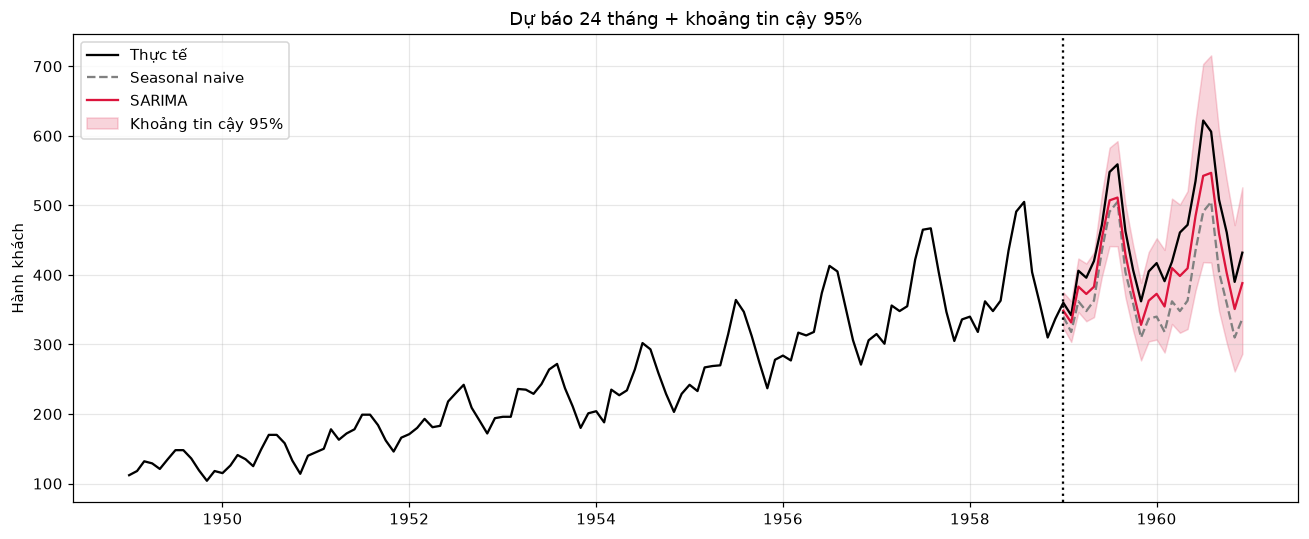

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y, label="Thực tế", color="black"); ax.plot(bl["Seasonal naive"], "--", color="gray", label="Seasonal naive")
ax.plot(mean, color="crimson", label="SARIMA"); ax.fill_between(ci.index, ci["thap"], ci["cao"], color="crimson", alpha=.18, label="Khoảng tin cậy 95%")
ax.axvline(test.index[0], color="k", ls=":"); ax.set_title("Dự báo 24 tháng + khoảng tin cậy 95%"); ax.legend(); ax.set_ylabel("Hành khách")
plt.tight_layout(); plt.savefig(f"{OUT}/du_bao_khoang.png"); plt.show()

## Lưu model

In [20]:
fit.save("../models/sarima_fit.pkl"); print("Đã lưu models/sarima_fit.pkl")

Đã lưu models/sarima_fit.pkl
